In [ ]:
# ========== Colab 上使用 Autoencoder 做 Anomaly Detection (MVTEC 資料集) ==========

# Step 1: 上傳 ZIP 資料檔
from google.colab import drive
drive.mount('/content/drive')

import tarfile

tar_path = "/content/drive/MyDrive/mvtec_anomaly_detection.tar.xz"
extract_dir = "/content/mvtec_data"

with tarfile.open(tar_path, "r:xz") as tar: # using 'with' to open compressed file
    tar.extractall(path=extract_dir)  # save the decompressed data to refered documents

print("✅ 解壓完成")




Mounted at /content/drive
✅ 解壓完成


In [ ]:
# Step 2: Package and Model Preparation
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict

# setting the device for latter model. Cuda means GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Step 3: Transform data to tensor type for later model training
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])



In [ ]:
# step 4: setting Autoencoder Model


class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # compress the original images
        # original image has 3 color channels (RGB).
        # generate 32 new images (called "feature maps").
        # Only look at a small 3x3 patch of the image at a time
        # The filter moves 2 pixels at a time, so the image gets smaller
        # Add a padding of 0s around the edges so the filter can cover the borders

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 8, 3, stride=2, padding=1), nn.ReLU()
            )

        # decompress the images
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid()
        )


    # The forward() method defines how data flows through the model.
    # PyTorch automatically calls this method when you run model(input).
    # Although the flow is designed by yourself, but you must name it "forward" — it cannot be changed.
    def forward(self, x):
        return self.decoder(self.encoder(x))

In [ ]:

train_path = "/content/mvtec_data/hazelnut/train"

# Image.Folder is used to import the images as a dataset
# trasform =transform use the preprocess that we defined previously
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"✅ Load {len(train_dataset)} training images")

✅ Load 391 training images


Epoch 1, Loss: 0.104938
Epoch 2, Loss: 0.094431
Epoch 3, Loss: 0.053993
Epoch 4, Loss: 0.035014
Epoch 5, Loss: 0.025962
Epoch 6, Loss: 0.013702
Epoch 7, Loss: 0.008091
Epoch 8, Loss: 0.007142
Epoch 9, Loss: 0.006588
Epoch 10, Loss: 0.005314
Epoch 11, Loss: 0.004188
Epoch 12, Loss: 0.003039
Epoch 13, Loss: 0.002283
Epoch 14, Loss: 0.001763
Epoch 15, Loss: 0.001465
Epoch 16, Loss: 0.001290
Epoch 17, Loss: 0.001104
Epoch 18, Loss: 0.000996
Epoch 19, Loss: 0.000919
Epoch 20, Loss: 0.000872
Epoch 21, Loss: 0.000826
Epoch 22, Loss: 0.000783
Epoch 23, Loss: 0.000756
Epoch 24, Loss: 0.000737
Epoch 25, Loss: 0.000710
Epoch 26, Loss: 0.000680
Epoch 27, Loss: 0.000671
Epoch 28, Loss: 0.000648
Epoch 29, Loss: 0.000637
Epoch 30, Loss: 0.000614
Epoch 31, Loss: 0.000604
Epoch 32, Loss: 0.000597
Epoch 33, Loss: 0.000586
Epoch 34, Loss: 0.000577
Epoch 35, Loss: 0.000570
Epoch 36, Loss: 0.000558
Epoch 37, Loss: 0.000554
Epoch 38, Loss: 0.000547
Epoch 39, Loss: 0.000548
Epoch 40, Loss: 0.000547
Epoch 41,

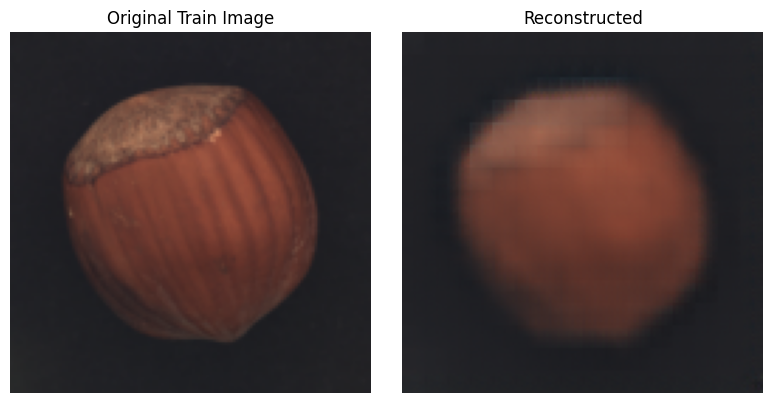

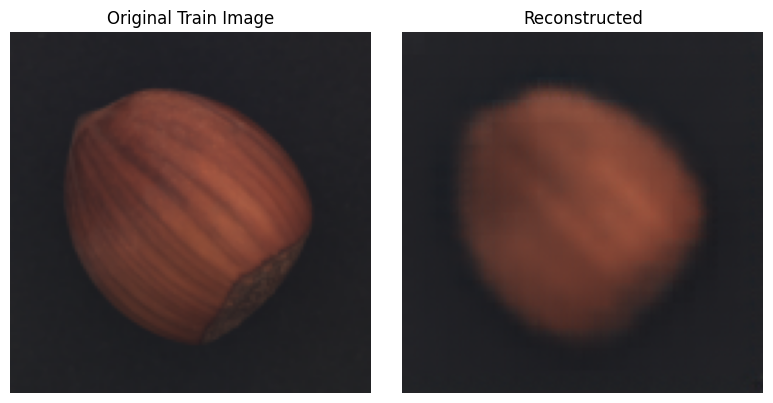

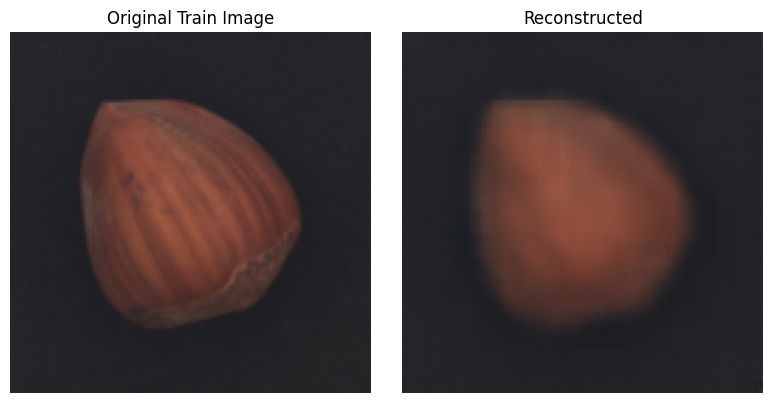

In [ ]:
# Step 5: model training
model = Autoencoder().to(device)
criterion = nn.MSELoss() # assign MEL as our loss function

# lr = learning rate
# Adam was used to update the parameter( will use the instruction called .step to update parameter)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(100):
    model.train()
    total_loss = 0
    for imgs, _ in train_loader:  #_ means we won't use the variable. Here the uselee variable is the label of image
        imgs = imgs.to(device)   # move to assigned tools (GPU or CPU)
        outputs = model(imgs)    # import image -> encode -> decode -> output
        loss = criterion(outputs, imgs) # calculate the loss between updated and orginal images
        optimizer.zero_grad() # 🔄 Clear the gradients from the previous step
        loss.backward()       # ⬅️ Compute gradients (derivatives) for the current loss
        optimizer.step()      # Update the parameter
        total_loss += loss.item() # Convert loss tensor to a Python float (by using .item) and add to total loss
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.6f}")  # calculate the average loss

model.eval() #change to evaluation mode
for i in range(3):  # test with the first 3 images in training set
    img, _ = train_dataset[i]
    input_tensor = img.unsqueeze(0).to(device)  # simulate with batch size equal to 1

    with torch.no_grad():  # invalid the grdient and restruction
        recon = model(input_tensor)

    img_np = img.permute(1, 2, 0).cpu().numpy()  # adjust the position of pratameters in order to show the image
    recon_np = recon.squeeze(0).permute(1, 2, 0).cpu().numpy() # remove the batch size and adiust the position of parameter to show reconstruction images

    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    axs[0].imshow(img_np)
    axs[0].set_title("Original Train Image")
    axs[1].imshow(recon_np)
    axs[1].set_title("Reconstructed")
    for ax in axs: ax.axis('off')
    plt.tight_layout()
    plt.show()




In [ ]:

# Step 5:  testing

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA


def display_anomalies_by_class(folder, threshold, top_k=3):
    model.eval()
    class_images = {}

    y_true = []  # ground truth: 1 = anomaly, 0 = normal
    y_pred = []  # prediction: 1 = anomaly, 0 = normal
    labels = []  # class name
    errors = []  # reconstruction error
    latent_vectors = []  # latent features

    image_files = []
    for subdir, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                image_files.append(os.path.join(subdir, f))

    print(f"\n📂 Total {len(image_files)} testing images")

    for path in tqdm(image_files):
        fname = os.path.basename(path)
        label = os.path.basename(os.path.dirname(path))
        img = Image.open(path).convert("RGB")
        img_tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            z = model.encoder(img_tensor)  # extract latent features
            recon = model.decoder(z)
            loss = criterion(recon, img_tensor).item()

        latent_flat = z.view(-1).cpu().numpy()

        # collect prediction and ground truth
        is_anomaly = 1 if loss > threshold else 0
        is_true_anomaly = 0 if label == 'good' else 1
        y_pred.append(is_anomaly)
        y_true.append(is_true_anomaly)
        labels.append(label)
        errors.append(loss)
        latent_vectors.append(latent_flat)

        if label not in class_images:
            class_images[label] = []

        class_images[label].append((fname, img_tensor, recon, loss))

    # Show results by class
    for label, items in class_images.items():
        print(f"\n🔍 Type：{label}（total number : {len(items)}）")

        total_loss = sum(x[3] for x in items)
        anomaly_count = sum(1 for x in items if x[3] > threshold)
        avg_loss = total_loss / len(items)

        print(f"🔹 Average Error: {avg_loss:.5f}")
        print(f"🔹 Anomalies: {anomaly_count} / {len(items)}")

        items.sort(key=lambda x: x[3], reverse=True)

        for i, (fname, img_tensor, recon, loss) in enumerate(items[:top_k]):
            status = "🟡 Anomaly" if loss > threshold else "🟢 Normal"
            print(f" {i+1}. {fname} - Error: {loss:.5f} - {status}")

            img_np = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
            recon_np = recon.squeeze(0).permute(1, 2, 0).cpu().numpy()

            fig, axs = plt.subplots(1, 2, figsize=(8, 4))
            axs[0].imshow(img_np)
            axs[0].set_title("Original")
            axs[0].axis('off')
            axs[1].imshow(recon_np)
            axs[1].set_title(f"Reconstructed\nError: {loss:.5f}")
            axs[1].axis('off')
            plt.suptitle(f"{label} - {status}", color='red' if loss > threshold else 'green')
            plt.tight_layout()
            plt.show()

    # 💡 Evaluation metrics
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print("\n📊 Overall Evaluation Metrics:")
    print(f"🔸 Precision: {precision:.4f}")
    print(f"🔸 Recall:    {recall:.4f}")
    print(f"🔸 F1 Score:  {f1:.4f}")

    # ✅ Return df for visualization
    df = pd.DataFrame({
        'label': labels,
        'true_label':  y_true,
        'pred_label':  y_pred,
        'error': errors,
        'latent': latent_vectors
    })
    return df

# You can call this function and use the result to plot additional visualizations
# df_result = display_anomalies_by_class(folder="/content/mvtec_data/hazelnut/test", threshold=0.00045, top_k=3)


📂 Total 110 testing images


100%|██████████| 110/110 [00:08<00:00, 13.66it/s]
<ipython-input-7-da02444f34b6>:82: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)



🔍 Type：good（total number : 40）
🔹 Average Error: 0.00030
🔹 Anomalies: 0 / 40
 1. 005.png - Error: 0.00047 - 🟢 Normal


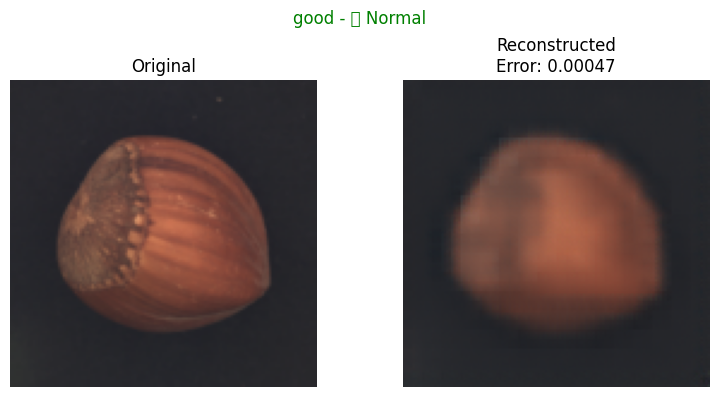

 2. 028.png - Error: 0.00044 - 🟢 Normal


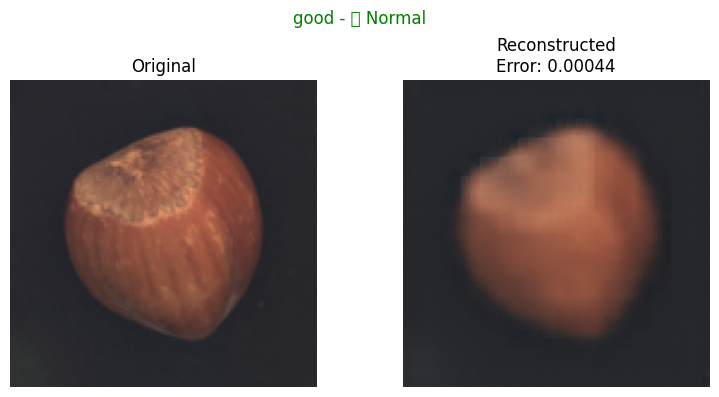

 3. 036.png - Error: 0.00041 - 🟢 Normal


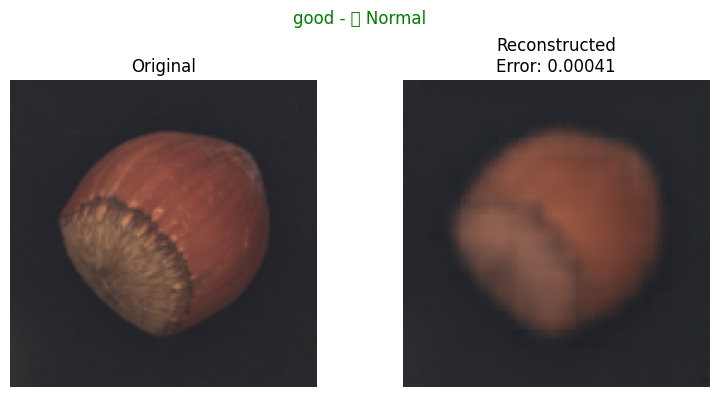


🔍 Type：cut（total number : 17）
🔹 Average Error: 0.00038
🔹 Anomalies: 1 / 17
 1. 015.png - Error: 0.00059 - 🟡 Anomaly


<ipython-input-7-da02444f34b6>:82: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


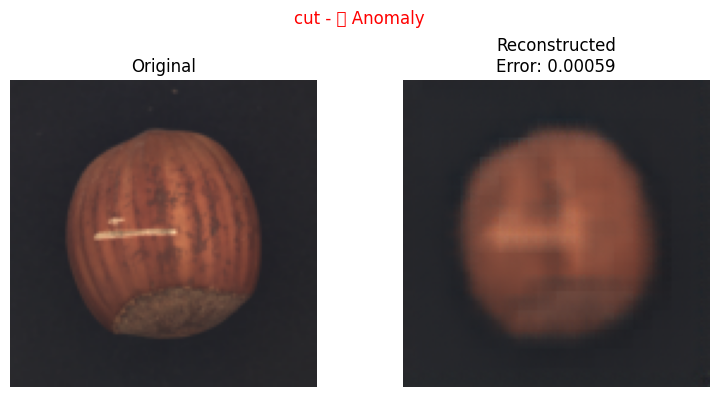

 2. 012.png - Error: 0.00049 - 🟢 Normal


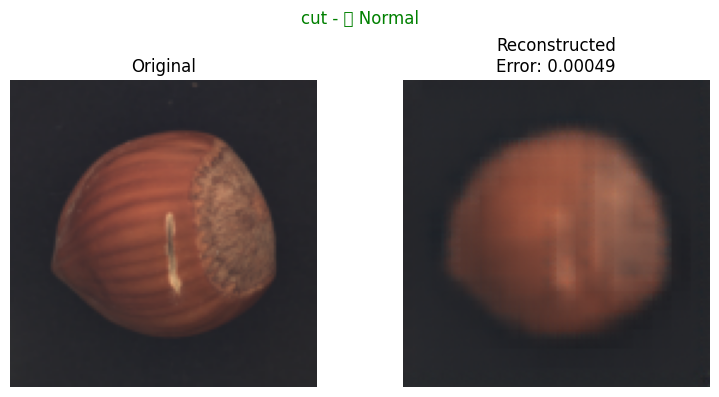

 3. 001.png - Error: 0.00048 - 🟢 Normal


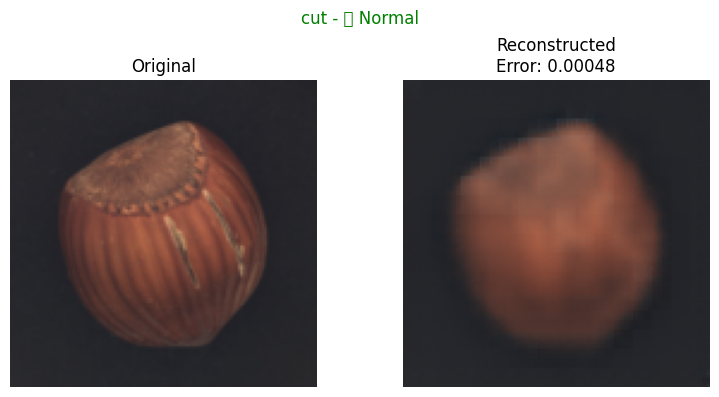


🔍 Type：crack（total number : 18）
🔹 Average Error: 0.00108
🔹 Anomalies: 11 / 18
 1. 010.png - Error: 0.00366 - 🟡 Anomaly


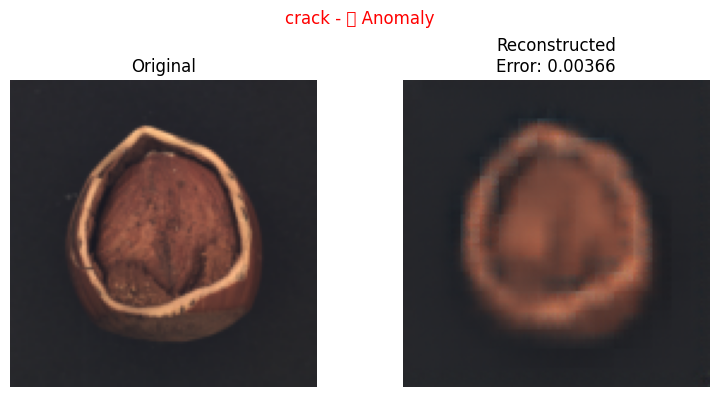

 2. 009.png - Error: 0.00264 - 🟡 Anomaly


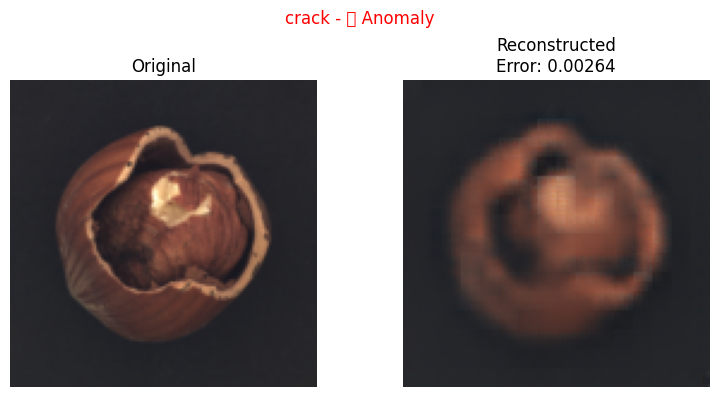

 3. 008.png - Error: 0.00202 - 🟡 Anomaly


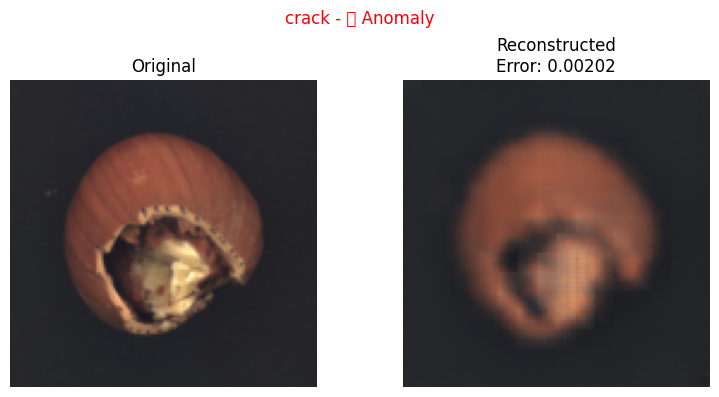


🔍 Type：hole（total number : 18）
🔹 Average Error: 0.00049
🔹 Anomalies: 8 / 18
 1. 010.png - Error: 0.00073 - 🟡 Anomaly


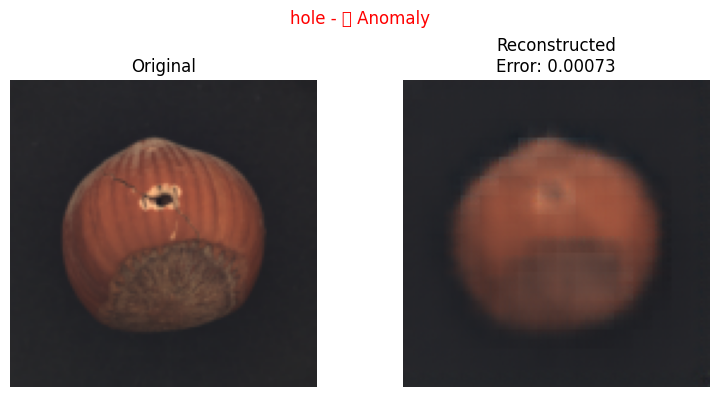

 2. 017.png - Error: 0.00067 - 🟡 Anomaly


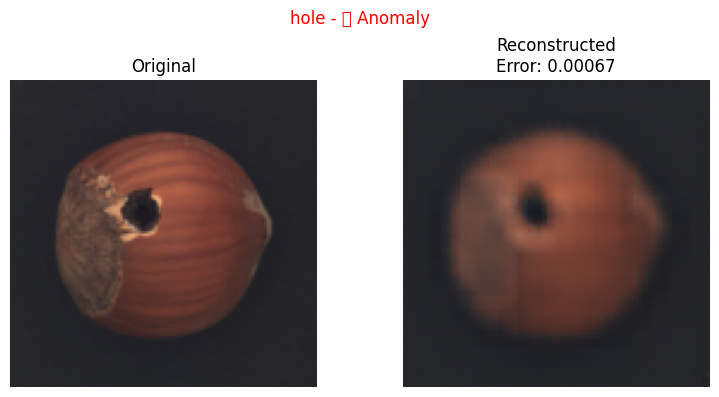

 3. 000.png - Error: 0.00065 - 🟡 Anomaly


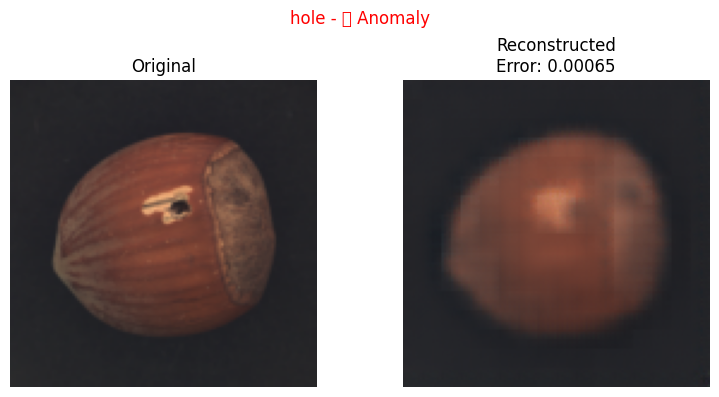


🔍 Type：print（total number : 17）
🔹 Average Error: 0.00187
🔹 Anomalies: 17 / 17
 1. 008.png - Error: 0.00413 - 🟡 Anomaly


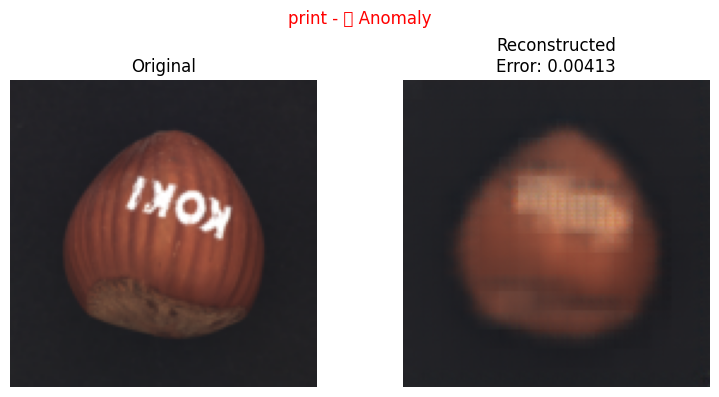

 2. 002.png - Error: 0.00276 - 🟡 Anomaly


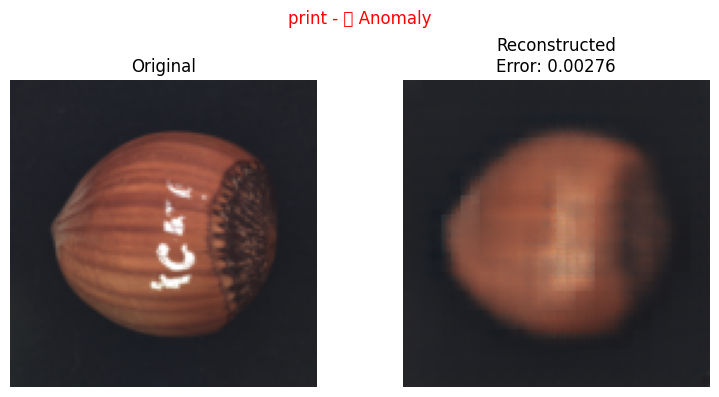

 3. 006.png - Error: 0.00275 - 🟡 Anomaly


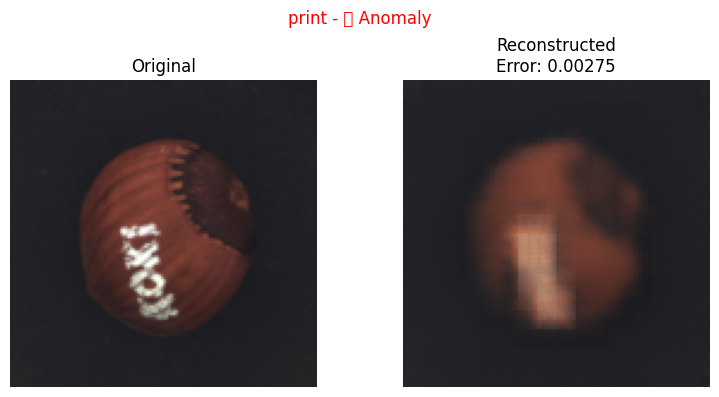


📊 Overall Evaluation Metrics:
🔸 Precision: 1.0000
🔸 Recall:    0.5286
🔸 F1 Score:  0.6916


In [ ]:
df_result = display_anomalies_by_class(
    folder="/content/mvtec_data/hazelnut/test",
    threshold=0.0005,
    top_k=3
)




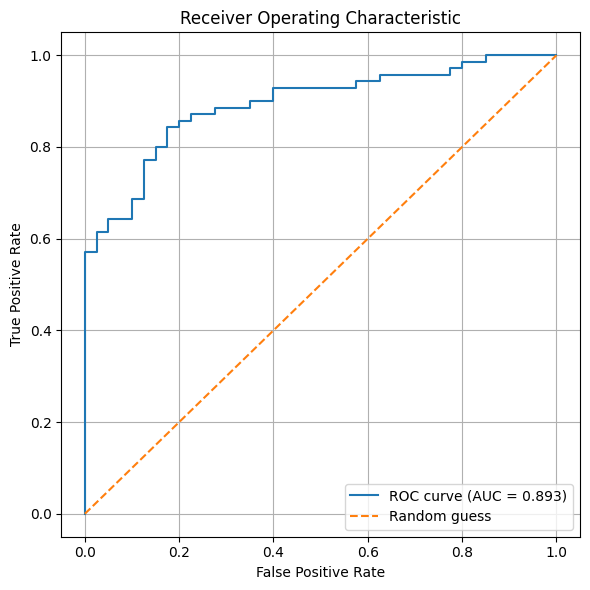

 threshold  accuracy  precision   recall
    0.0005  0.700000        1.0 0.528571
    0.0010  0.545455        1.0 0.285714
    0.0015  0.490909        1.0 0.200000
    0.0020  0.463636        1.0 0.157143
    0.0025  0.427273        1.0 0.100000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_score, recall_score, accuracy_score

# 1. 从 df_result 取出真实标签和分数
y_true  = df_result['true_label']
y_score = df_result['error']

# 2. 计算 ROC 曲线和 AUC
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score, pos_label=1)
roc_auc = auc(fpr, tpr)

# 3. 画 ROC 曲线
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# —— 如果你还想看几个固定阈值下的性能 —— #
thresholds_to_test = [0.0005, 0.001, 0.0015, 0.002, 0.0025]
rows = []
for thr in thresholds_to_test:
    y_pred = (y_score > thr).astype(int)
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    rows.append({
        'threshold': thr,
        'accuracy':  acc,
        'precision': pre,
        'recall':    rec
    })

df_metrics = pd.DataFrame(rows)
print(df_metrics.to_string(index=False))


,precision,recall,f1-score,support
Normal,0.547945,1.000000,0.707965,40.0
Anomaly,1.000000,0.528571,0.691589,70.0
accuracy,0.700000,0.700000,0.700000,0.7
macro avg,0.773973,0.764286,0.699777,110.0
weighted avg,0.835616,0.700000,0.697544,110.0


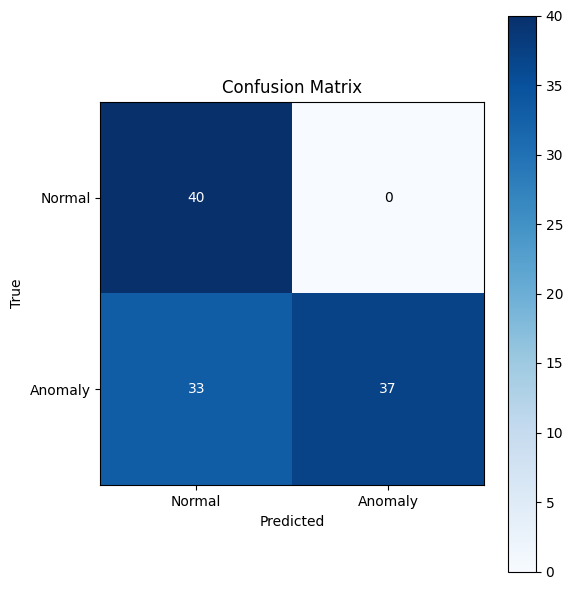

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from IPython.display import display  # Jupyter自带

# 假设 df_result 已经在内存里，且有 true_label / pred_label 两列
y_true = df_result['true_label']
y_pred = df_result['pred_label']

# 1) Performance Table
report = classification_report(y_true, y_pred, output_dict=True)
df_perf = pd.DataFrame(report).T
df_perf.rename(index={'0': 'Normal', '1': 'Anomaly'}, inplace=True)

# 在 Jupyter/Colab 里渲染
display(df_perf)

# 2) Confusion Matrix 可视化
labels = [0, 1]
label_names = ['Normal', 'Anomaly']
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(len(labels)),
    yticks=np.arange(len(labels)),
    xticklabels=label_names,
    yticklabels=label_names,
    xlabel='Predicted',
    ylabel='True',
    title='Confusion Matrix'
)

# 在每个格子里写数字
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, format(cm[i, j], 'd'),
            ha='center', va='center',
            color='white' if cm[i, j] > thresh else 'black'
        )

plt.tight_layout()
plt.show()


In [ ]:
df_result['anomaly'] = df_result['error'] > 0.00045
print(df_result.groupby('label')['anomaly'].mean())

label
crack    0.666667
cut      0.235294
good     0.025000
hole     0.500000
print    1.000000
Name: anomaly, dtype: float64


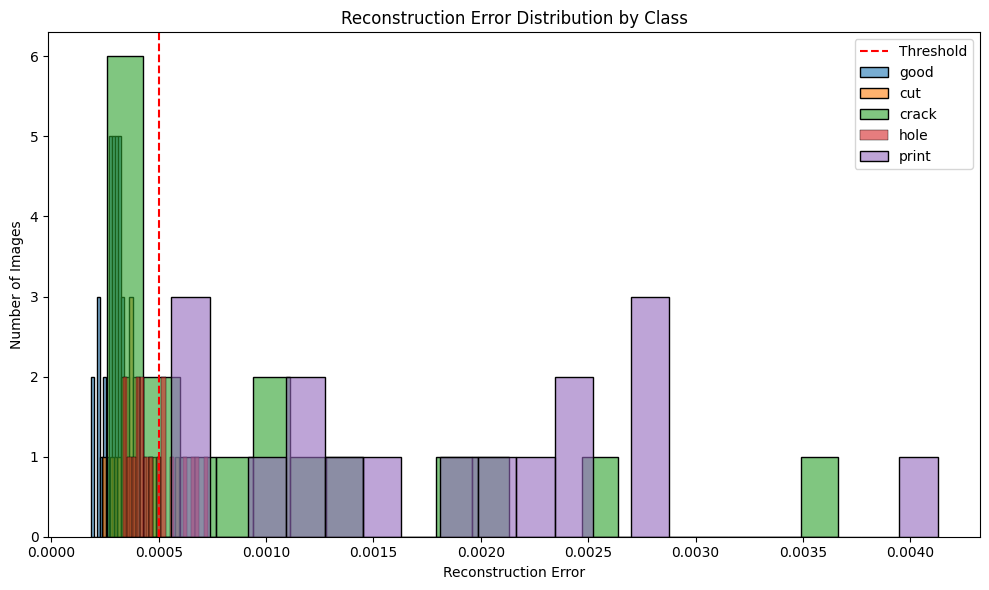

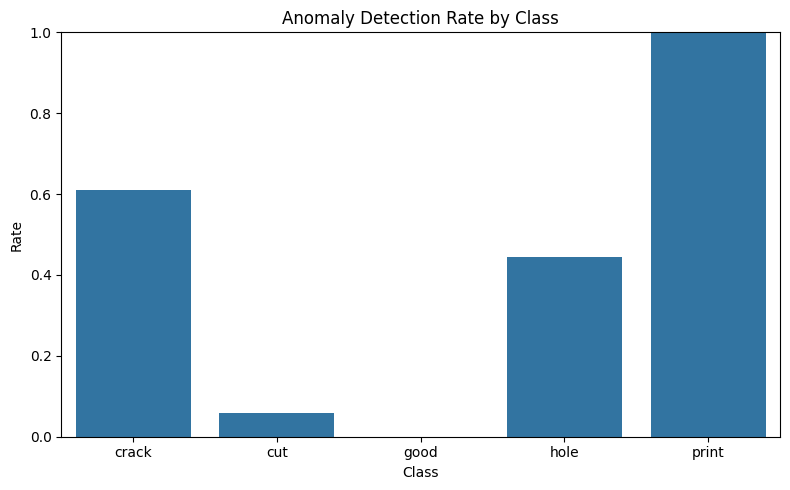

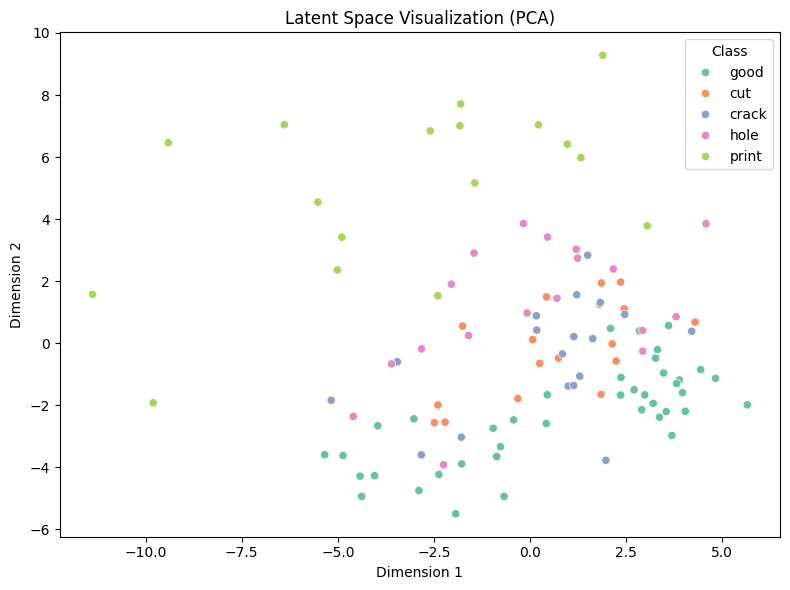

In [ ]:
import seaborn as sns

def plot_error_distribution(df, threshold=0.0005):
    plt.figure(figsize=(10, 6))
    for label in df['label'].unique():
        subset = df[df['label'] == label]  # ✅ 加上這行
        sns.histplot(subset['error'], kde=False, bins=20, label=label, alpha=0.6)
    plt.axvline(x=threshold, color='red', linestyle='--', label='Threshold')
    plt.title('Reconstruction Error Distribution by Class')
    plt.xlabel('Reconstruction Error')
    plt.ylabel('Number of Images')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_anomaly_rate(df, threshold=0.0005):
    df['anomaly'] = df['error'] > threshold
    summary = df.groupby('label')['anomaly'].mean().reset_index()
    summary.columns = ['Class', 'Anomaly Rate']
    summary['Anomaly Rate'] = summary['Anomaly Rate'].astype(float)

    plt.figure(figsize=(8, 5))
    sns.barplot(x='Class', y='Anomaly Rate', data=summary)
    plt.ylim(0, 1)
    plt.title('Anomaly Detection Rate by Class')
    plt.ylabel('Rate')
    plt.tight_layout()
    plt.show()  # ✅ 加上括號

def plot_latent_space(df):
    latent_matrix = np.vstack(df['latent'].values)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(latent_matrix)

    df['pca-1'] = pca_result[:, 0]
    df['pca-2'] = pca_result[:, 1]

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x='pca-1', y='pca-2', hue='label', palette='Set2')
    plt.title('Latent Space Visualization (PCA)')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.legend(title='Class')
    plt.tight_layout()
    plt.show()

plot_error_distribution(df_result)
plot_anomaly_rate(df_result)
plot_latent_space(df_result)

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Get report
report = classification_report(y_true, y_pred, output_dict=True)

# Extract desired values
precision = report['weighted avg']['precision']
recall = report['weighted avg']['recall']
f1 = report['weighted avg']['f1-score']
accuracy = report['accuracy']

# Create clean summary table
summary_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1 Score', 'Accuracy'],
    'Value': [precision, recall, f1, accuracy]
})

print(summary_df)


      Metric     Value
0  Precision  0.835616
1     Recall  0.700000
2   F1 Score  0.697544
3   Accuracy  0.700000
